# <center>Motivation</center>

<p align="justify">In this file, we are going to test some machine learning classification algorithms that can predict diabetes cases.</p>

## <div id = "1">1) Importing libraries</div>

<p align="justify">In order to create a machine learning model that can estimates whether a patient has or has not tendencies with diabetes, we need to import libraries that can handle machine learning and data analysis workflows.</p>

<ul>
    <li>Third party packages:
        <ul>
            <li>
                <b><a href = "https://matplotlib.org/stable/index.html" target="blank">matplotlib</a></b>: to customize and create our own graphs in order to understand the data;
            </li>
            <li>
                <b><a href = "https://numpy.org/doc/stable/" target="blank">numpy</a></b>: to work and handle data more efficiently;
            </li>
            <li>
                <b><a href = "https://docs.pola.rs/api/python/stable/reference/index.html" target="blank">polars</a></b>: for fast data manipulation;
            </li>
            <li>
                <b><a href = "https://scikit-learn.org/stable/">scikit-learn</a></b>: for data algoritms;
            </li>
            <li>
                <b><a href = "https://www.tensorflow.org/learn?hl=pt-br">tensorflow</a></b>: to create neural networks;
            </li>
        </ul>
    </li>
    <li>Functions:
        <ul>
            <li>
                <b><a href = "./functions/plots.py" target="blank">plots</a></b>: to help create plots already determined;
            </li>
            <li>
                <b><a href = "./functions/statistics.py" target="blank">statistics</a></b>: to help calculate values more easy;
            </li>
        </ul>
    </li>
</ul>

In [45]:
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, make_scorer, f1_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import RidgeClassifier, SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import numpy as np

# import tensorflow as tf

import polars as pl

import joblib

from functions import plots

## 2) Reading dataset

### 2.1) Importing <code>.parquet</code> dataset

In [23]:
dataset = pl.read_parquet(
    source = "./dataset/cleaned_dataset.parquet"
)

print(
    f'Estimated size:, {dataset.estimated_size(unit = "mb"):.3f}Mb'
)
print(dataset.shape)
dataset.head(2)

Estimated size:, 2.494Mb
(249049, 20)


HIGHT_BLOOD_PRESURE,HAS_HIGHT_CHOLESTEROL,HAS_CHECKED_CHOLESTEROL,IS_SMOKER,HAD_STROKE,HAD_HEARTH_ATTACK_OR_DISEASE,HAVE_EXERCISED,HAD_FRUITS,HAD_VEGGIES,CONSUME_ALCOOL,HAS_HEALTHCARE,NO_DOCTOR_APPOINTMENT_BY_COST,BODY_MASS,DAYS_BAD_MENTAL_HEALTH,AGE_RANGE,EDUCATION_LEVEL,DIABETES_LEVEL,PCA_HEALTH_&_INJURY_&_WALK_DIFFICULTY,SEX_female,SEX_male
bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,i8,i8,i8,i8,enum,f16,i8,i8
true,true,true,true,false,false,false,false,true,false,true,false,4,2,8,3,"""no_diabetes""",2.396484,1,0
false,false,false,true,false,false,true,false,false,false,false,true,1,0,6,5,"""no_diabetes""",0.357422,1,0


### 2.2) Plotting <code>DIABETES_LEVEL</code> imbalance

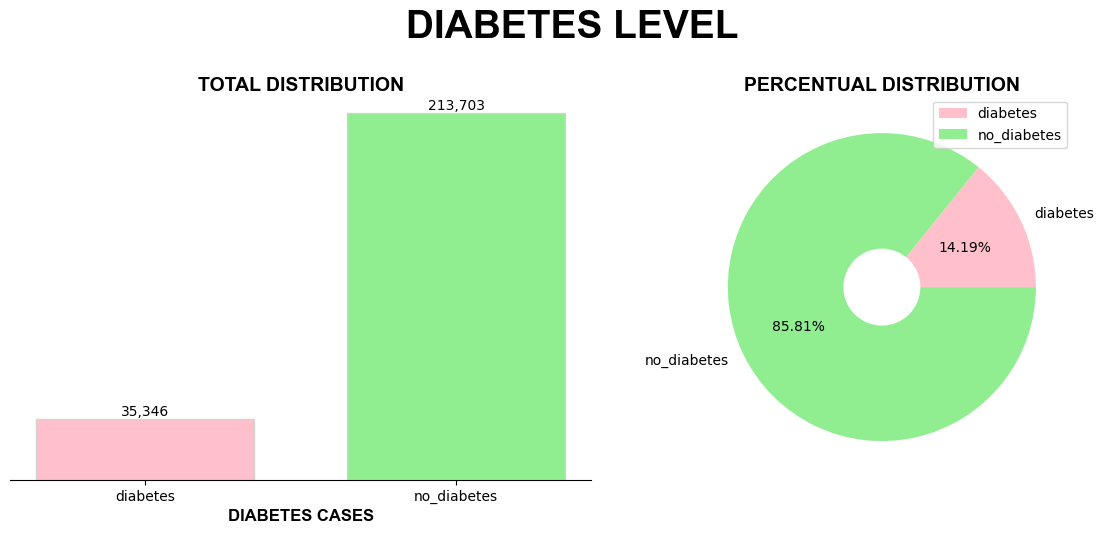

In [24]:
fig, axs = plt.subplots(
    figsize = (15, 5),
    ncols = 2,
    gridspec_kw = {
        "wspace": .0
    }
)

# Getting total and relative frequency for each category in DIABETES_LEVEL:
plot_df = dataset.group_by(
    ["DIABETES_LEVEL"]
).agg(
    pl.col("DIABETES_LEVEL").len().cast(pl.Int32).alias("TOTAL")
).with_columns(
    (pl.col("TOTAL")/pl.col("TOTAL").sum()).alias("PERCENTAGE")
).sort(
    "TOTAL"
)

# Setting a bar plot for total cases in DIABETES_LEVEL
plots.plot_bar(
    ax = axs[0],
    x_values = plot_df["DIABETES_LEVEL"],
    y_values = plot_df["TOTAL"],
    colors = ["pink", "lightgreen",],
    legends = plot_df["DIABETES_LEVEL"],
    formater = "{:,.0f}",
    title = {
        "text": f"TOTAL DISTRIBUTION",
        "font": "arial",
        "size": 14,
    },
    x_label = {
        "text": "DIABETES CASES",
        "font": "arial",
        "size": 12,
    },
    y_label = {
        "text": "",
        "font": "arial",
        "size": 12
    },
    width = .7,
    tooltip_align = "edge"
)

# Setting a pie plot for percentual cases in DIABETES_LEVEL:
plots.plot_pie(
    ax = axs[1],
    values = plot_df["PERCENTAGE"],
    labels = plot_df["DIABETES_LEVEL"],
    colors = ["pink", "lightgreen",],
    title = {
        "text": f"PERCENTUAL DISTRIBUTION",
        "font": "arial",
        "size": 14,
    },
)

plt.legend()
plt.suptitle("DIABETES LEVEL", fontsize = 28, y = 1.05, fontname = "arial", fontweight = "bold")
plt.show()

### 2.3) Handling imbalance

In [25]:
random_sampler = RandomUnderSampler(
    random_state = 1
)

X_resampled , y_resampled = random_sampler.fit_resample(
    X = dataset.drop("DIABETES_LEVEL").to_pandas(),
    y = dataset["DIABETES_LEVEL"].to_pandas()
)

## 3) Testing models

### 3.1) Linear models:

#### 3.1.1) RidgeClassifier

<small>Recall: 0.78224</small>

In [48]:
custom_recall = make_scorer(f1_score, pos_label='diabetes')

ridge_grid_search = GridSearchCV(
    estimator = RidgeClassifier(),
    param_grid = {
        "alpha": [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1, 1.5, 2],
        "solver": ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    },
    cv = 5,
    n_jobs = -1,
    verbose = 1,
    scoring = {
        "f1": custom_recall
    },
    refit = 'f1',
    error_score = "raise",
)

ridge_grid_search.fit(
    X = X_resampled.astype('float32'),
    y = y_resampled
)

print(f"Best f1_score: {ridge_grid_search.best_score_:.4f}")

joblib.dump(
    value = ridge_grid_search.best_estimator_,
    filename = "./models/ridge.joblib"
)

Fitting 5 folds for each of 63 candidates, totalling 315 fits
Best f1_score: 0.7577


['./models/ridge.joblib']

#### 3.1.2) SGDClassifier

<small>f1_score: 0.7703</small>

In [50]:
SGD_grid_search = GridSearchCV(
    estimator = SGDClassifier(),
    param_grid = {
        "loss": ['hinge', 'log_loss', 'perceptron', 'squared_error', 'huber'],
        "penalty": ['l2', 'l1', 'elasticnet'],
        "alpha": [0.0001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        "l1_ratio": [0.0001, 0.001, 0.01, 0.02, 0.05, 1]
    },
    cv = 5,
    n_jobs = -1,
    verbose = 1,
    scoring = {
        "f1": custom_recall
    },
    refit = 'f1',
    error_score = "raise",
)

SGD_grid_search.fit(
    X = X_resampled.astype('float32'),
    y = y_resampled
)

print(f"Best f1_score: {SGD_grid_search.best_score_:.4f}")

joblib.dump(
    value = SGD_grid_search.best_estimator_,
    filename = "./models/SGD.joblib"
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best f1_score: 0.7703


['./models/SGD.joblib']

#### 3.1.2) LogisticRegression

<small>f1_score: 0.7563</small>

In [55]:
logistic_grid_search = GridSearchCV(
    estimator = LogisticRegression(),
    param_grid = {
        "penalty": ['l2'],
        "solver": ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
        "C": [0.0001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    },
    cv = 5,
    n_jobs = -1,
    verbose = 1,
    scoring = {
        "f1": custom_recall
    },
    refit = 'f1',
    error_score = "raise",
)

logistic_grid_search.fit(
    X = X_resampled.astype('float32'),
    y = y_resampled
)

print(f"Best f1_score: {logistic_grid_search.best_score_:.4f}")

joblib.dump(
    value = logistic_grid_search.best_estimator_,
    filename = "./models/logistic.joblib"
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best f1_score: 0.7563


['./models/logistic.joblib']

### 3.2) Models based on distances: 

#### 3.2.1) KNeighborsClassifier

In [ ]:
kneighbors_grid_search = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid = {
        "n_neighbors": [5, 7, 10, 15, 20, 30],
        "weights": ['uniform', 'distance'],
        "algorithm": ['auto'],
        "leaf_size": [20, 30, 40],
        "p": [1, 2]
    },
    cv = 5,
    n_jobs = -1,
    verbose = 1,
    scoring = {
        "f1": custom_recall
    },
    refit = 'f1',
    error_score = "raise",
)

kneighbors_grid_search.fit(
    X = X_resampled.astype('float32'),
    y = y_resampled
)

print(f"Best f1_score: {kneighbors_grid_search.best_score_:.4f}")

joblib.dump(
    value = kneighbors_grid_search.best_estimator_,
    filename = "./models/kneighbors.joblib"
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


### 3.3) Tree models

In [ ]:
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

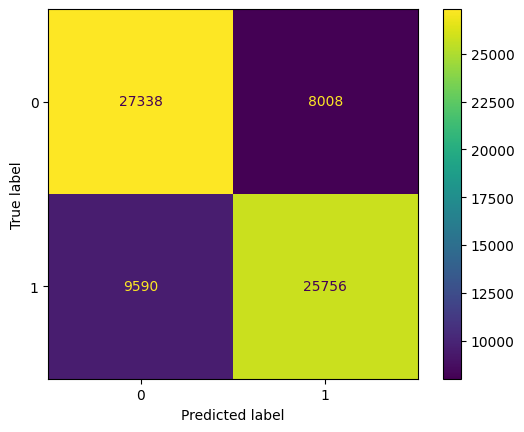

In [ ]:
cm_plot = ConfusionMatrixDisplay(
    confusion_matrix = confusion_matrix(
        y_pred = kneighbors_grid_search.best_estimator_.predict(X = X_resampled),
        y_true = y_resampled
    )
)

cm_plot.plot()